### Lecture 17

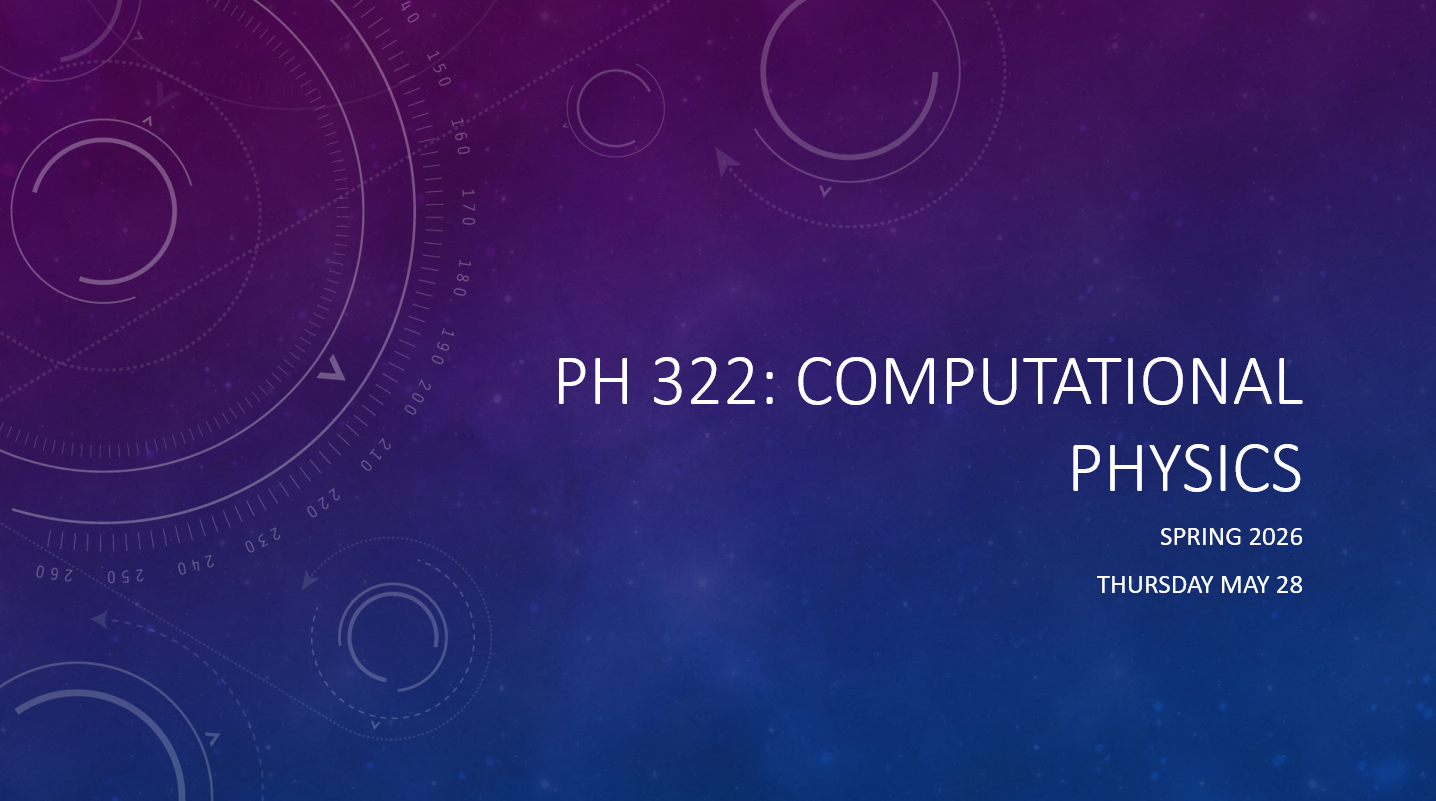

In [1]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Lectures\\Figures\\header_lecture17.png"))

* Grace period for HW 8 due tonight.
* HW 9 available. I will post HW 10 next week, but it is optional. If you choose to do, the points will add to your total. 
* Let me know if you wish to present your student project next week.


**Last Class**

* Fourier Series
* Fourier Transform
* Discrete Fourier Transform (DFT)
* Inverse DFT
* DFT of a sampled function


**Today's Class**
* DFT of numerical data
* Interpretation of DFT
* DFT of real functions
* Discrete cosine transform (DCT)
* Fast Fourier transform (FFT)


### Discrete Fourier Transform (review)

In last class we derived the  **discrete Fourier transform**. We can think of it as a way of calculating the coefficients or weights for each sinusoidal term in our Fourier series, or alternatively as a mapping of our function or sampled from the time or space domain into the frequency (temporal or spatial) domain. The coefficients $\gamma_k$ are complex and tell us both the magnitude and phase of the $k$-th harmonic or term in the series.

As a matter of notation we will refer to the members of the DFT as $c_k$, such that 

$$
\boxed{c_k =  \sum_{n=0}^{N-1}y_n\exp{\left(-i\frac{2\pi kn}{N}\right)}}
$$

and the Fourier coefficients are 

$$
\gamma_k = \frac{1}{N} c_k
$$



The **inverse discrete Fourier transform**:

$$
\boxed{y_n = \frac{1}{N}\sum_{k=0}^{N-1}c_k\exp{\left(i\frac{2\pi kn}{N}\right)}}
$$

Being the inverse of the DFT, the inverse DFT of course has a similar form. This says that we can recover the original sampled data $y_n$ from the members of the DFT $c_k$. Note the sign of the exponential term has changed (this is the complex conjugate).



#### Coding the DFT

To compute the full set of $c_k$'s, we need to use a nested ```for``` loop. The outer loop will iterate over each $c_k$, and the inner loop will perform the sum from n=0, N-1 for each coefficient. 

The pseudocode for the DFT might look like:

* Define the number of sample points $N$ if we are sampling a function. Otherwise $N$ is determined by number of data points. 
* Sample the function at these points.
* Create an array to store the DFT coefficients. These will be complex. 
* Decide the max coefficient to calculate, $k_max$.
* Calculate each $c_k$ by looping from $k=0, k_max$.
    * Within this loop, loop from $n=0, N-1$, multiplying each sample $y_n$ by the exponential term and summing each term.



### Practice exercise - Discrete Fourier Transform of a continuous function

Write a program that calculates the DFT for the function $f(x) = x^2$ over $x=-1$ to $x=1$.  Sample the function using $N = 100$ points, and calculate $c_k$ for $k=0$ to $k=N-1$.

Make a plot of the DFT, i.e., plot $c_k$ vs. $k$.  

Notes:
* Use either the ```exp()``` function from ```numpy``` or from the ```cmath``` module to work with complex numbers.
* Remember in Python, the imaginary number $i$ is denoted by ```j```.
* Since the coefficients are complex, plot only the real components by using the ```abs()``` function.
* If you use an array to store the coefficients, initialize it for complex variables.


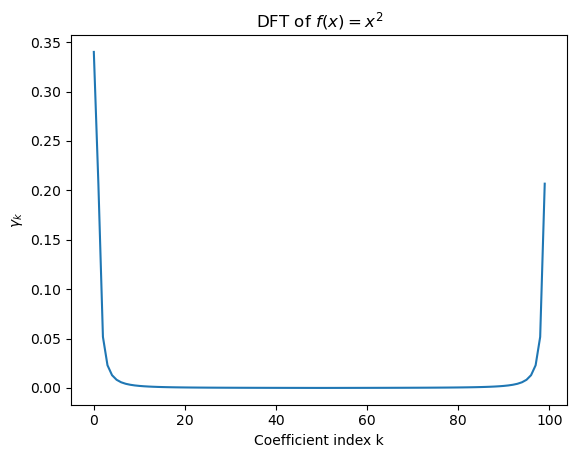

In [4]:
### Practice exercise - DFT of function f(x) = x^2


### Practice Exercise: Inverse DFT

Once you have your program above working to calculate the DFT of $f(x)=x^2$, take the inverse DFT of your coefficients to reproduce the original sample data. 

Plot your inverse DFT against the original sampled data.  

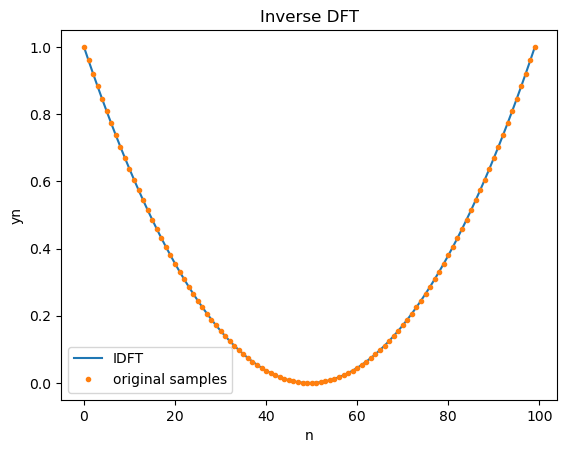

In [5]:
# practice exericse - calculate inverse DFT.  This cell uses info from previous cell.



### Application of the DFT to a time series of measurements

Next let's apply this and calculate the DFT for a time series of real data. In this case, we will work with a data set of monthly carbon dioxide (CO2) measurements taken from Mauna Loa. We used this data set earlier this term.  Note to run the following code you will need to download the file "monthly_in_situ_co2_mlo_2026.txt" and put in your working directory. 

First we will plot the data:

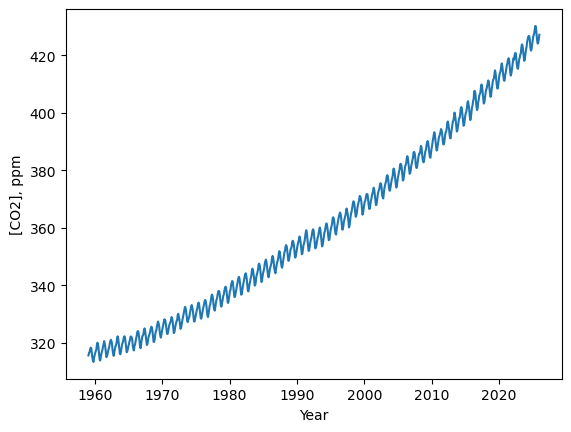

In [9]:
# Calculate DFT of Mauna Loa CO2 data

import numpy as np
from cmath import exp, pi
import matplotlib.pyplot as plt

# directory path to data file
path = "G:\\My Drive\\Classes\\Ph322\\Data files\\"
file = "monthly_in_situ_co2_mlo_2026.txt"

# load in the file "monthly_in_situ_co2_mlo.txt"
data = np.loadtxt(path+file)
#data = np.loadtxt(file)
# col 2 contains date in units of days
day = data[:,2]
# col 3 contains date in units of years
year = data[:,3]
# col 4 contains CO2 in units of ppb
co2 = data[:,4]

#plot CO2 vs year
plt.plot(year, co2, '-')
plt.xlabel("Year")
plt.ylabel("[CO2], ppm")
plt.show()

Again we see that the data has a seasonal cycle with a large upward trend.

Now let us calculate the DFT, that is calculate the coefficients $c_k$. 

$$
c_k =  \sum_{n=0}^{N-1}y_n\exp{\left(-i\frac{2\pi kn}{N}\right)}
$$

As noted above, all the information from a data set of $N$ members is stored in the coefficients $c_k$ from $k=0, N-1$. So we need to calculate $c_0, c_1, \ldots, c_{N-1}$. 

In this case, the $y_n$'s are the monthly measurements of CO2. 


In [10]:
# Calculate DFT of Mauna Loa CO2 data




Here you see I am passing my co2 data to my function. The function returns a 1D complex array that holds all N coefficients. Let's go ahead and plot the coefficients. Since the coefficients are complex I plot the real part by using the abs() function.

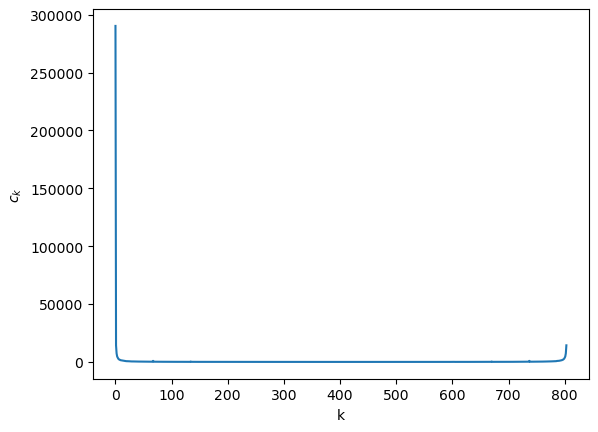

In [11]:
# plot the DFT

plt.plot(abs(c), '-')
plt.xlabel("k")
plt.ylabel(r"$c_k$")
plt.show()

You see we get a big spike at the first $c_k$, overwhelming all other values. If we look at the DFT,

$$
c_k =  \sum_{n=0}^{N-1}y_n\exp{\left(-i\frac{2\pi kn}{N}\right)}
$$

when k=0, we see 

$$
c_0=  \sum_{n=0}^{N-1}y_n
$$ 

and is just the sum of all of the data samples. If all the samples are positive, like here, $c_k$ will be very large. 



In [12]:
N = len(co2)
sum = np.sum(co2)
print(f"Number of measurements: {N}")
print(f"Sum of data: {sum}")

Number of measurements: 804
Sum of data: 290283.68


Since we typically don't care about the constant term we can subtract the mean from the dataset and recalculate the DFT.

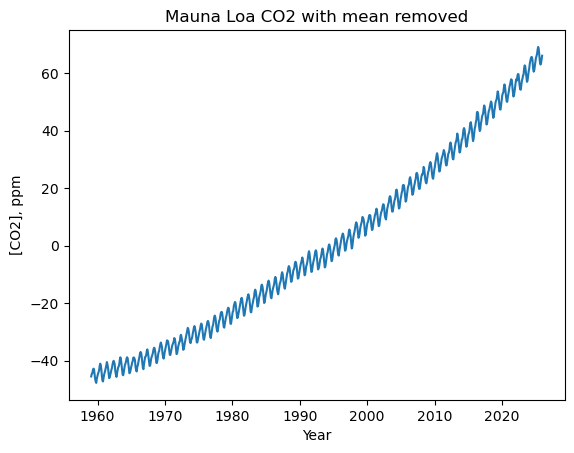

7.048583938740194e-12


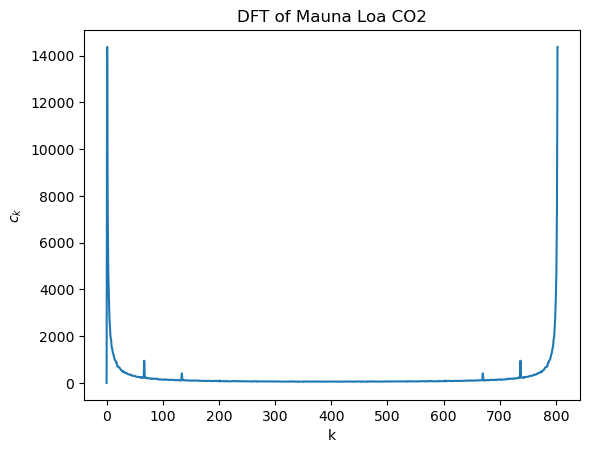

In [13]:
# Calculate DFT for Mauna Loa CO2 data with mean removed
# This code uses the co2 array and DFT function from above. 

# Subtract the mean of the data set from each measurement.
co2 = co2 - np.mean(co2)

#plot CO2 vs year
plt.plot(year, co2, '-')
plt.xlabel("Year")
plt.ylabel("[CO2], ppm")
plt.title("Mauna Loa CO2 with mean removed")
plt.show()

# calculate the DFT of the CO2 time series
c = dft(co2)

# plot the DFT
plt.plot(abs(c), '-')
plt.xlabel("k")
plt.ylabel(r"$c_k$")
plt.title("DFT of Mauna Loa CO2")


print (abs(c[0]))

Now we see some interesting features in the DFT. 

First we see a very large spike, two actually, which we return to below. 

We also see some smaller spikes at higher values of k or higher frequencies. 

We also see smaller but continuous harmonics in between these spikes with an amplitude that decreases with $k$. 

Finally we see the spectrum is repeated in the second half of the plot, there is symmetry about the midpoint of the frequency interval. 

This is an expected result when working with real functions, or in this case real data. In fact, we only have to calculate $c_k$ for $k$ up to $N/2+1$. We will discuss why this result occurs below.

**Period of peak component**


The maximum occurs at k=1. What is the period of this harmonic? To answer, let's again look at our equation for the DFT:


$$
c_k =  \sum_{n=0}^{N-1}y_n\exp{\left(-i\frac{2\pi kn}{N}\right)}
$$

The frequency of the harmonic is given by:

$
\omega = \frac{2\pi k}{N}
$

$n$ here acts as the x-coordinate so is not part of the frequency.

Since the period $T$ is related to $\omega$ as:

$$
T=\frac{2\pi}{\omega},
$$

we get: 

$
T=N/k.
$

The number of data points $N=804$, so at $k=1$, $T=804$. 

What are the units of $T$? 

Well the MLO data in the file are monthly, so the period is given in units of month. So $T=804$ months, which is 67 years, the length of our data record. Interesting. 

What we found then, is the frequency component with the largest magnitude has a period equal to the length of our data record. Why?

Well, let's look at the data again. The main feature we see other than the seasonal cycle is the upward trend. The upward trend is antisymmetric, i.e. lower in the first half of the time series and higher in the second half.

What sinusoidal function could fit this? Well, just a sine wave with a period equal to the entire record.

Let's see this. 

The following code allows us to reconstruct our data series by summing the terms in the Fourier series. We can specify how many terms we wish to sum, by setting kmax. 

To plot up to the first term, set kmax=1. To plot all terms set kmax=N-1.

Let's first look at the first term, k=0.

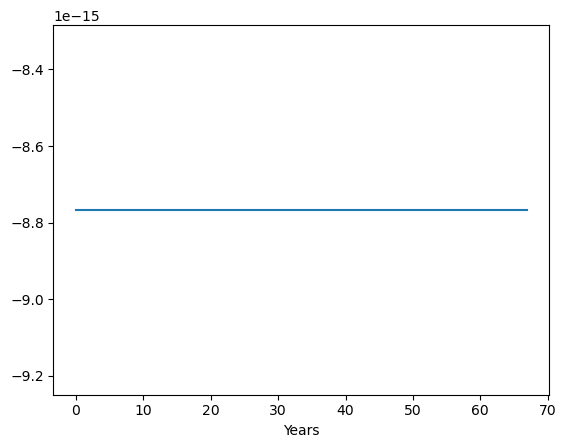

In [37]:
# code allows us to calculate, plot the sum of the first kmax terms of the Fourier series
# using DFT calculated above

# Add Fourier series terms up to kmax term. kmax = N-1 
kmax=0

xvalues = np.arange(0,N,1)
yvalues = np.empty([N,N], complex)
sum = np.zeros([len(xvalues)], complex)

# build up function by adding Fourier terms
for k in range(0,kmax+1):
    omega = 2*np.pi*k/N
    for x in range(N):
        sum[x] += (c[k]/N)*exp(1j*omega*xvalues[x])
          
plt.plot(xvalues/12,sum)
plt.xlabel("Years")
plt.show()

We see this is just the constant offset we talked about. If we removed the mean from our data set, the constant term will be zero. 

Now add in the next term, kmax=1:

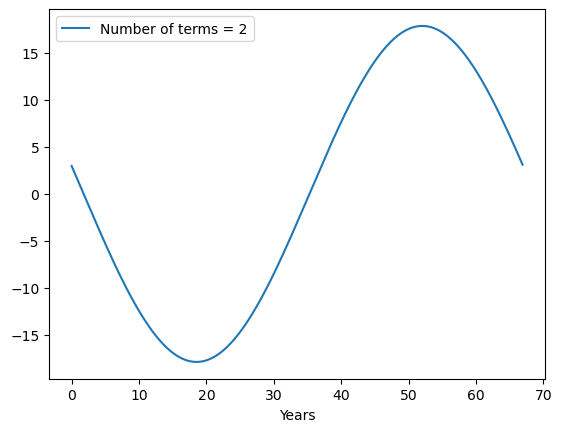

In [38]:
# code allows us to calculate, plot the sum of the first kmax terms of the Fourier series
# using DFT calculated above

# Add Fourier series terms up to kmax term. kmax = N-1 
kmax = 1

xvalues = np.arange(0,N,1)
yvalues = np.empty([N,N], complex)
sum = np.zeros([len(xvalues)], complex)

# build up function by adding Fourier terms
for k in range(0,kmax+1):
    omega = 2*np.pi*k/N
    for x in range(N):
        sum[x] += (c[k]/N)*exp((1j*omega)*xvalues[x])
          
plt.plot(xvalues/12,sum, label=f"Number of terms = {kmax+1}")
plt.legend()
plt.xlabel("Years")
plt.show()

This is term with a period of 817 months. You can see it is the first harmonic of the sine series. It is needed to approximate the large trend in the CO2 record.

Now slowly increase kmax and replot. 

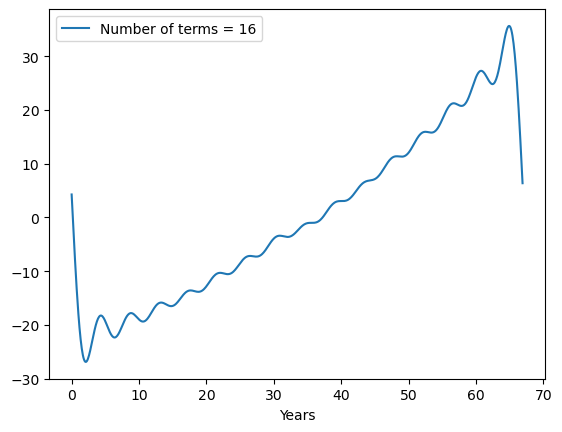

In [39]:
# code allows us to calculate, plot the sum of the first kmax terms of the Fourier series
# using DFT calculated above


# Add Fourier series terms up to kmax term. kmax = N-1 
kmax = 15

xvalues = np.arange(0,N,1)
yvalues = np.empty([N,N], complex)
sum = np.zeros([len(xvalues)], complex)

# build up function by adding Fourier terms
for k in range(0,kmax+1):
    omega = 2*np.pi*k/N
    for x in range(N):
        sum[x] += (c[k]/N)*exp((1j*omega)*xvalues[x])
        
plt.plot(xvalues/12,sum, label=f"Number of terms = {kmax+1}")
plt.legend()
plt.xlabel("Years")
plt.show()

You see slowly we get back the original data series. Which of course isn't surprising, but is a good check that our code is working. 

If we add up all the terms by setting kmax=N-1, we get back the original time series.

So we see the first term represents the longterm trend of the time series. 

Let's calculate the periods of the other two peaks, i.e. the peaks in the lower half of the plot.

Zoom the DFT plot in around the second peak:

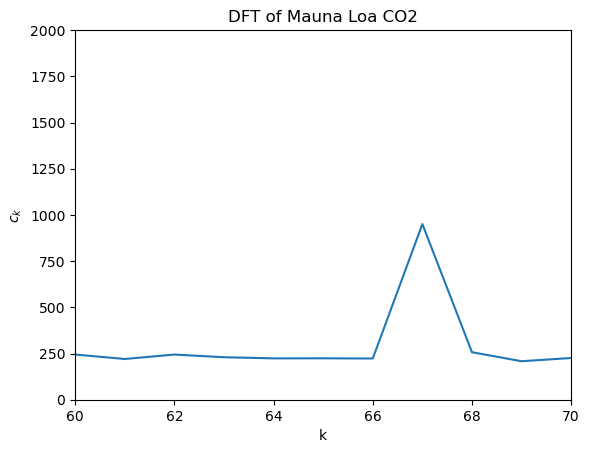

In [40]:
# plot the DFT
plt.plot(abs(c), '-')
plt.xlim(60,70)
plt.ylim(0,2000)
plt.xlabel("k")
plt.ylabel(r"$c_k$")
plt.title("DFT of Mauna Loa CO2")
plt.show()


The k index of the second highest peak occurs at k=67.  

The period of this component is, using $T=N/k$, is 12 months. 

Well this makes sense. This is the component that corresponds to the seasonal cycle of CO2. As we see from this graph, it is a strong signal, so not surprising it stands out. 

Finally, let's look at the third peak:

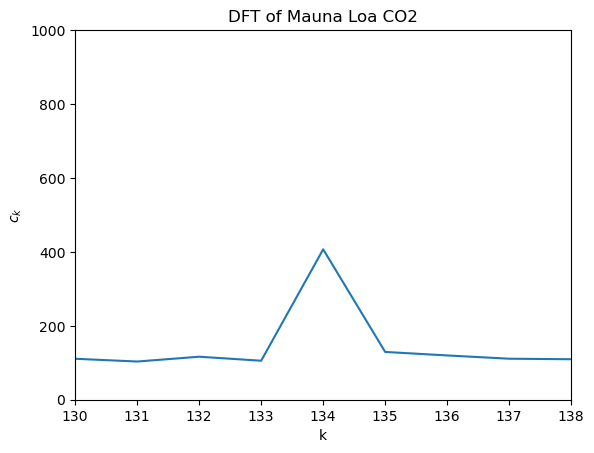

In [42]:
# plot the DFT
plt.plot(abs(c), '-')
plt.xlim(130,138)
plt.ylim(0,1000)
plt.xlabel("k")
plt.ylabel(r"$c_k$")
plt.title("DFT of Mauna Loa CO2")
plt.show()

This is occurs at k=134 or 6 months. 

Is there a natural or human process that would repeat twice a year? 

Maybe. 

But more than likely this is a harmonic of the 12-month term. Because the seasonal cycle of CO2 is not exactly a sine or cosine wave, if we were to subtract a waveform with a 12-month term, we will get residuals that vary twice as fast. So this third peak arises likely because of this effect.

### Simplification of the DFT for real functions


If our function is real, for example sampled measurements like above, there's a trick we can use to reduce the number of computations we have to perform in calculating the DFT.


Suppose we have $N$ sampled points, i.e., we have $y_n$ for n=0, N-1. For this data set we compute the $c_k$ from the DFT. Suppose we look at a particular $c_k$ where $k$ is in the second half of the data set, i.e., $k$ is greater than $N/2$ and less than $N$. We write $k$ as $k=N-r$ where $1\le r< \frac{1}{2}N$.

Then using our DFT equation:

$$
c_k =  \sum_{n=0}^{N-1}y_n\exp{\left(-i\frac{2\pi kn}{N}\right)}
$$



$$
c_{N-r} =  \sum_{n=0}^{N-1}y_n\exp{\left(-i\frac{2\pi (N-r)n}{N}\right)}=\sum_{n=0}^{N-1}y_n\underbrace{\exp{(-i2\pi n)}}_{=1}\exp{\left(i\frac{2\pi rn}{N}\right)}
$$

where the first exponential equals 1 since $e^{-i\theta}=\cos{\theta}-i\sin{\theta}$ and $\theta$ is a multiple of $2\pi$. 

Therefore we can write this as:

$$
c_{N-r} = \sum_{n=0}^{N-1}y_n\exp{\left(i\frac{2\pi rn}{N}\right)}
$$


However this is just $c_r^*$, the complex conjugate of $c_r$,  that is $c_r$ with the sign of the imaginary part flipped. 

So

$$
c_{N-r}= c_r^*
$$

That means $c_{N-1}= c_1^*$, $c_{N-2}= c_2^*$, $\ldots$  

Therefore we only have to calculate half of the coefficients, the other half are just the complex conjugates of the first half so the real parts will be the same.

The general rule is:

We calculate $c_k$ for $0\le k \le \frac{1}{2}N$, e.g., if $N=8$, we calculate $c_k$ for $k=0,1,2,3,4$ or a total of $\frac{1}{2}N+1$ coefficients if $N$ is even, and $\frac{1}{2}(N+1)$ when $N$ is odd. Calculating only half the coefficients, reduces the computation time. However, if we reconstruct the data from $c_k$, we still need to consider the complex conjugates.

Note: You can perform integer division in Python using ```//```. which removes the decimal part of the result. To determine the number of coefficients to calculate, you can use ```N//2 + 1```.

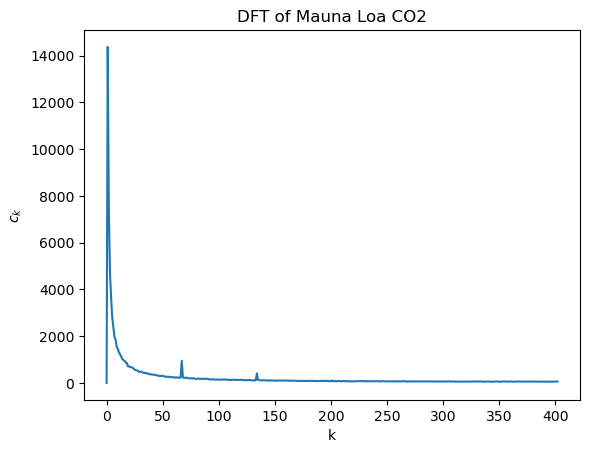

In [14]:
# Calculate only the first half of the DFT of Mauna Loa CO2 data 



# calculate the DFT of the CO2 time series
c = realdft(co2)

# plot the absolute value of DFT
plt.plot(abs(c), '-')
plt.xlabel("k")
plt.ylabel(r"$c_k$")
plt.title("DFT of Mauna Loa CO2")
plt.show()

Now construct the full set of coefficients by taking the complex conjugate of the first half. You can use the ```numpy``` function ```np.conjugate()``` to take the complex conjugate. 

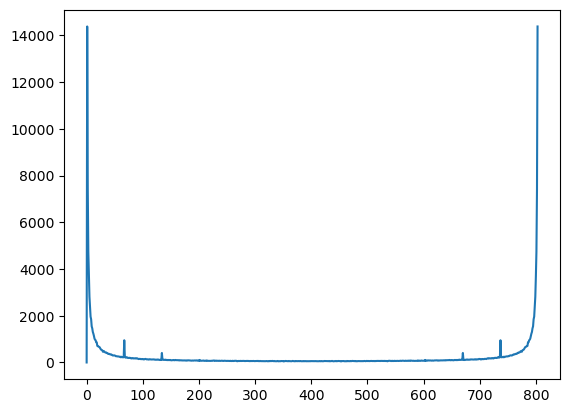

In [15]:
# construct the full set of coefficients by taking the conjugate of the first half

# number of DFT coefficients from above. This contains only the first half of the coefficients
N = len(c)

# total number of coefficients in full data set equals the number of data
Ndata = len(co2)

# create array to store full DFT
c_full = np.empty(Ndata, complex)

# fill the first half of the array with the half DFT
c_full[0:N] = c

# fill the second half of array by taking the complex conjugate of the first half
for r in range(1,Ndata//2):
    c_full[Ndata-r] = np.conjugate(c[r]) 

plt.plot(abs(c_full))
plt.show()

Once we have the full DFT calculated, we can take the inverse DFT to recover the original data. 

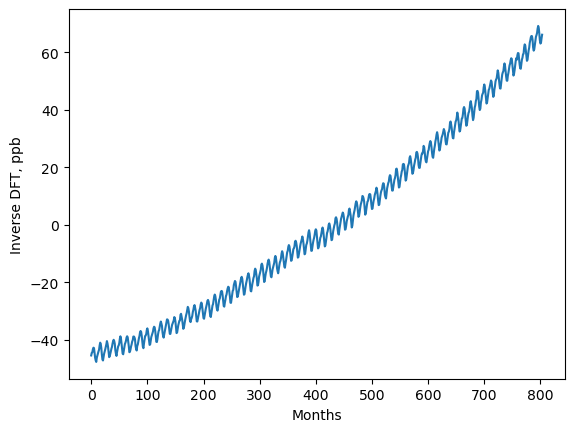

In [22]:
# Take the inverse DFT of the reconstituted full DFT

# c_full - contains the full set of coefficients. Calculated above.
# Ndata - number of measurements. Calculated above. 

# for plotting
nvalues = np.arange(0,Ndata,1)

# y will store the reconstructed data from the inverse DFT
y = np.zeros(Ndata, complex)

# loop over and calculate each y_n data point
for n in nvalues:
    # sum up all k terms
    for k in range(Ndata):
        y[n] += (c_full[k]/Ndata)*exp(1j*2*np.pi*k*n/Ndata)
  
   
# plot the reconstructed data against the nvalues, i.e. the "x-axis"
# Note use .real not abs() since we removed the mean making some of the y_n negative. 
plt.plot(nvalues,y.real)
plt.xlabel("Months")
plt.ylabel("Inverse DFT, ppb")
plt.show()


So we can recover the original data set by calculating one half of the DFT and using the complex conjugate for the other half. 

### Discrete cosine transform 

The discrete cosine transform is a type of Fourier transform that uses only cosines to represent our function $f(x)$ or our data $y_n$.

It is not intuitively obvious what advantage a discrete cosine transform (DCT) has over the general discrete Fourier transform (DFT). So to help motivate the advantages of the DCT, I am going to go back to my DFT of the Mauna Loa carbon dioxide data set.

Again, I first plot the data then I plot its DFT.

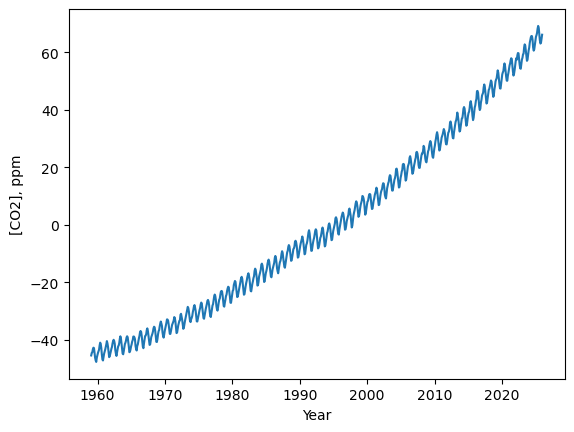

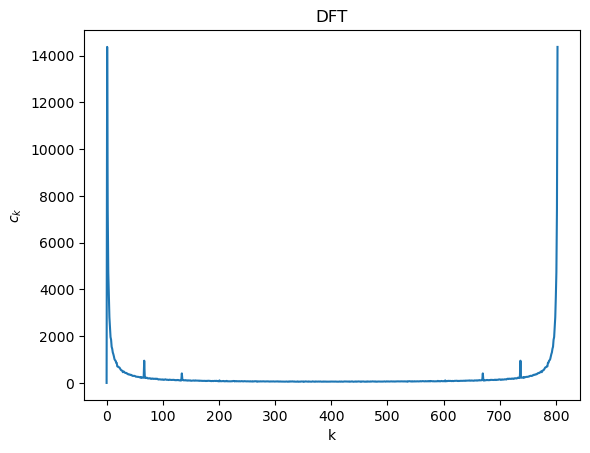

In [53]:
# Calculate DFT for Mauna Loa CO2 data with mean removed


# calculate the DFT of the CO2 time series
c = dft(co2)

# plot the DFT
plt.plot(abs(c), '-')
plt.xlabel("k")
plt.ylabel(r"$c_k$")
plt.title("DFT")
plt.show()

I am again going to calculate the inverse DFT, that is recover the original data set using the DFT coefficients $c_k$ I calculated above.

However, this time I am going to plot the inverse DFT over a range that extends beyond the original range of the data set. That is, instead of plotting the inverse DFT just from n=0, N-1, I am going to plot over the range -2N, 2N. Let's see what it looks like:

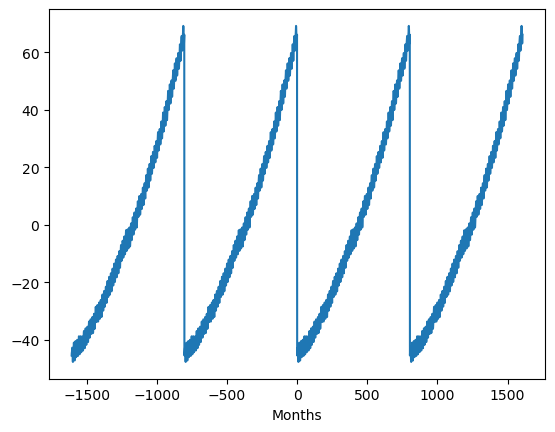

In [56]:
# Plot the sum of the first kmax terms of the Fourier series
# using DFT calculated above

import numpy as np
import matplotlib.pyplot as plt

N = len(c)
kmax = N-1 # Add Fourier series terms up to kmax term

xvalues = np.arange(-2*N,2*N,1)
yvalues = np.empty([N,N], complex)

yn = np.zeros([len(xvalues)], complex)
for k in range(0,kmax+1):
     omega = 2*np.pi*k/N
     for x in range(len(xvalues)):
           yn[x] += (c[k]/N)*exp((1j*omega)*xvalues[x])
          
plt.plot(xvalues,yn)
plt.xlabel("Months")
plt.show()

Interesting! We see that when we plot the recovered function (or in this case our recovered data) beyond the interval we originally sampled it,  the function just repeats itself. If we were to extend this graph to infinity in both directions, the pattern would continue.

If you remember from last class, we said there is an exact one-to-one correspondence between the information stored in the DFT and the information stored in the inverse DFT. 

This means that in the "eyes" of the DFT the data set we are transforming is in fact this periodic function. This is the function the DFT is "trying" (from a teleological viewpoint) to approximate. If we represent our data set as the function $f(x)$ then $f(x)=f(x+N)$. 

One problem is this function has discontinuities in it. You can see that the function drops from about 60 at the end of each period to -40 at the next point. 

This discontinuity is difficult to represent with sinusoids. And while the DFT can indeed do this, it takes a lot of terms to do so. This explains why we see a lot of non-zero coefficients in the plot of the DFT. These are necessary in order for the Fourier series to approximate the above periodic function of our data set.

In the plot below I zoom into the DFT so I can see these non-zero coefficients.

(0.0, 300.0)

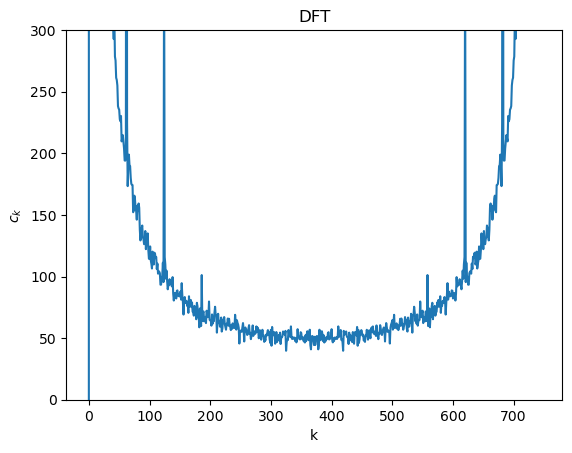

In [14]:
# plot the DFT and zoom in to see the non-zero coefficients
plt.plot(abs(c), '-')
plt.xlabel("k")
plt.ylabel(r"$c_k$")
plt.title("DFT")
plt.ylim(0,300)

Now if you are using a DFT to identify signals or periodicities in your data, these sinusoids needed to represent the discontinuties may end up masking the true signals in the data. In other cases, such as the case here with the CO2, it may not matter so much if the physical signals have coefficients large enough to stand above the background.


However in the case where Fourier transforms are used for data compression, e.g. compressing images or audio, the additional sinusoids needed to represent these discontinuities will decrease the efficiency of the compression method, making for larger data sizes. 

### DFTs and compression


Let's say I want to transmit this data set of CO2 to a colleague. Let's assume that the file size of the raw data is quite large, too large for my colleague to handle on their slow internet service.

Instead I have the brilliant idea that instead of transmitting the data itself, I will transmit the DFT of it, knowing that all the information that is in the original data is stored in the DFT itself. 

Once receiving my DFT my colleague will be able to recover the data by calculating the inverse DFT.

Now if I transmitted all the coefficients from the DFT, there would be no gain in efficiency, since for N measurements there are N coefficients.

However, I realize that many if not most of the coefficients are quite small, meaning they contribute very little information to the data set. Therefore I can omit these coefficients from the DFT with no significant information loss. I then only have to transmit the largest coefficients to my colleague, which could be a significant decrease in file size.

What percentage of coefficients can I drop?

Well that depends on my data set (or function) and how much information loss I am willing to live with.

**Omitting coefficients**

Let's experiment.

Let's first drop the *smallest half* of the coefficients. This also includes the complex conjugates since these are needed to reconstruct the data set.

In the code below, I first define what percentile of coefficients to drop.  I use the numpy function ```np.percentile``` to find the value of the $c$ array at that percentile. I locate the indicies of all coefficients below that threshold using the numpy function ```np.argwhere()``` which returns the set of the indicies where the logical expression is true.

I then set all these coefficients to zero, which effectively removes them from the DFT.

Finally I reconstruct the data from this filtered DFT. I plot the reconstructed data and the difference between the original data set and the reconstructed data.

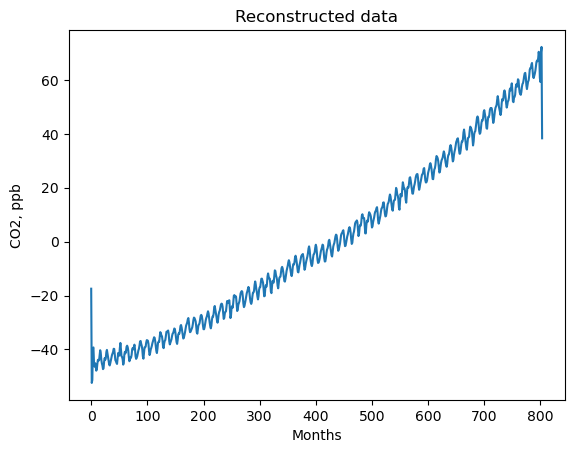

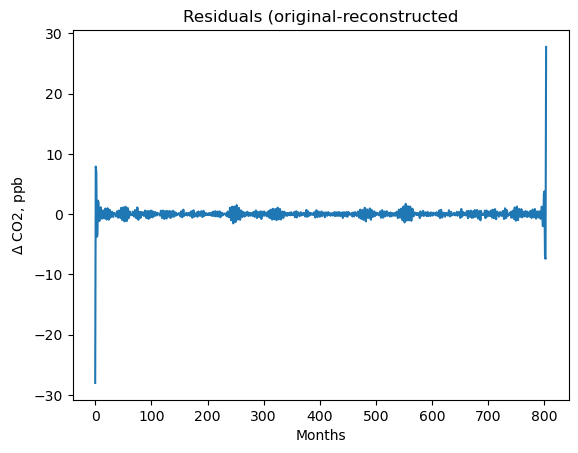

In [57]:
# Remove (or zero out) DFT coefficients below a specified percentile and reconstruct the data set


# plot the inverse DFT with 50% of DFT terms removed
plt.plot(nvalues,yn)
plt.xlabel("Months")
plt.ylabel("CO2, ppb")
plt.title("Reconstructed data")
plt.show()

# calculate the differences between reconstructed data and original data
residuals = co2-np.real(yn)

# plot the residuals
plt.plot(nvalues,residuals)
plt.xlabel("Months")
plt.ylabel(r"$\Delta$ CO2, ppb")
plt.title("Residuals (original-reconstructed")
plt.show()

This is what the reconstructed data set looks like after removing the lower half of the DFT coefficients. You can see we can still recover most of the information from the original data set, including the trend and seasonal cycle. However, removing half of the coefficients leaves significant artefacts at the endpoints of the data set. This is because we removed those components that are needed to match the discontinuities we saw above.

Let's try a lower threshold and remove only the lowest 25% of the data.

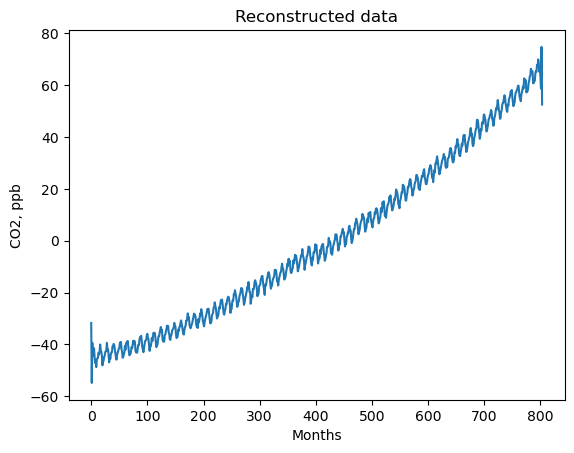

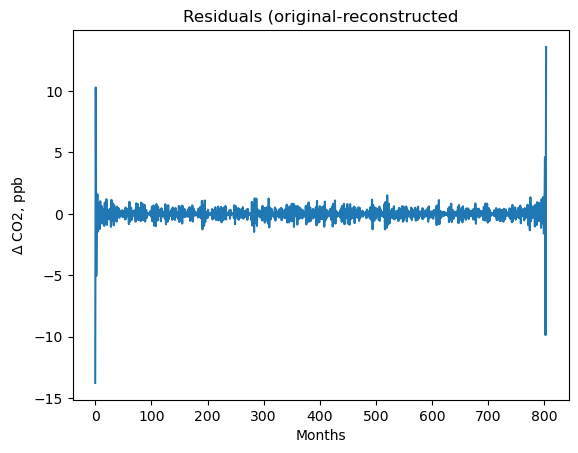

In [58]:
# Remove (or zero out) DFT coefficients below a specified percentile and reconstruct the data set

         

# plot the inverse DFT with 25% of DFT terms removed
plt.plot(nvalues,yn)
plt.xlabel("Months")
plt.ylabel("CO2, ppb")
plt.title("Reconstructed data")
plt.show()

# calculate the differences between reconstructed data and original data
residuals = co2-np.real(yn)

# plot the residuals
plt.plot(nvalues,residuals)
plt.xlabel("Months")
plt.ylabel(r"$\Delta$ CO2, ppb")
plt.title("Residuals (original-reconstructed")
plt.show()

We see now that the residuals were reduced by about half, but still significant residuals remain. 

How about 10% of the coefficients? 

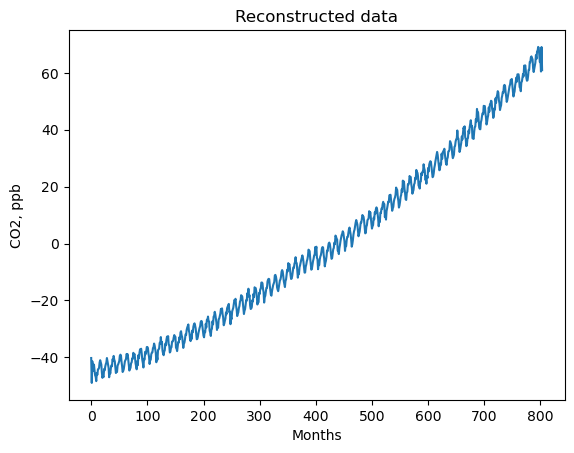

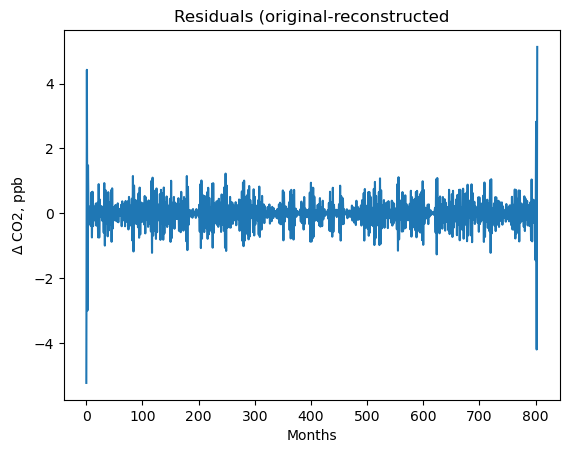

In [59]:
# Remove 10% of the DFT coefficients and reconstruct the data set


# plot the inverse DFT with 10% of DFT terms removed
plt.plot(nvalues,yn)
plt.xlabel("Months")
plt.ylabel("CO2, ppb")
plt.title("Reconstructed data")
plt.show()

# calculate the differences between reconstructed data and original data
residuals = co2-np.real(yn)

# plot the residuals
plt.plot(nvalues,residuals)
plt.xlabel("Months")
plt.ylabel(r"$\Delta$ CO2, ppb")
plt.title("Residuals (original-reconstructed")
plt.show()




Even if we remove only 10% of the coefficients, we're still getting sizable residuals. In fact we need to keep all but 1% of the DFT to entirely get rid of the residuals at the end points. 

I hope this illustrates one of the disadvantages of the general DFT. For non-symmetric functions or datasets, which will be the case for most real-world data, the DFT needs a lot of coefficients to represent the data without introducing artefacts. 

Can we do better? Yes, enter the discrete cosine transform (DCT).

### The Discrete Cosine Transform

As mentioned above the discrete cosine transform is another type of Fourier transform, except now we represent our function or data set with only cosine functions. 

When we use only cosine functions to approximate our function or data set, the resulting Fourier series is still an infinite periodic function, just like the Fourier series we used for the DFT. However the way the periodic function is built is different.


As we discussed above the general Fourier series produces a periodic function that simply repeats the function sampled from 0 to L over and over in both directions like this:

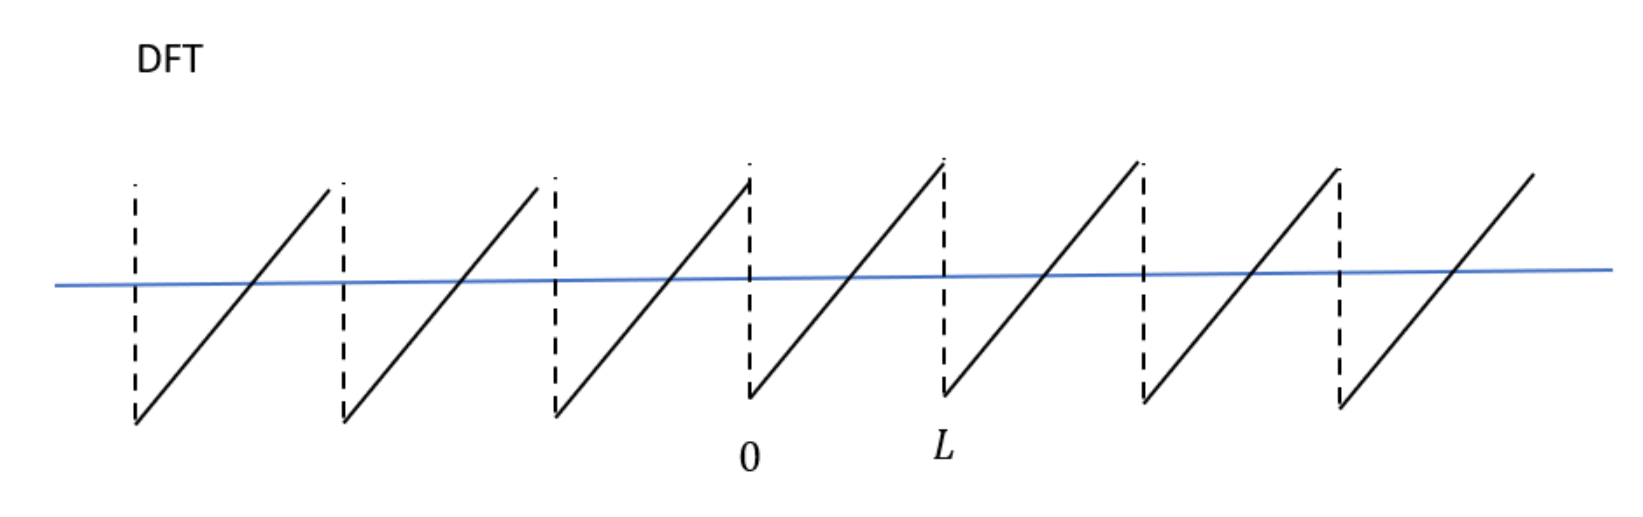



As we noted before and we can see, this produces discontinuities in the function.

The cosine series produces a periodic function that looks like this:

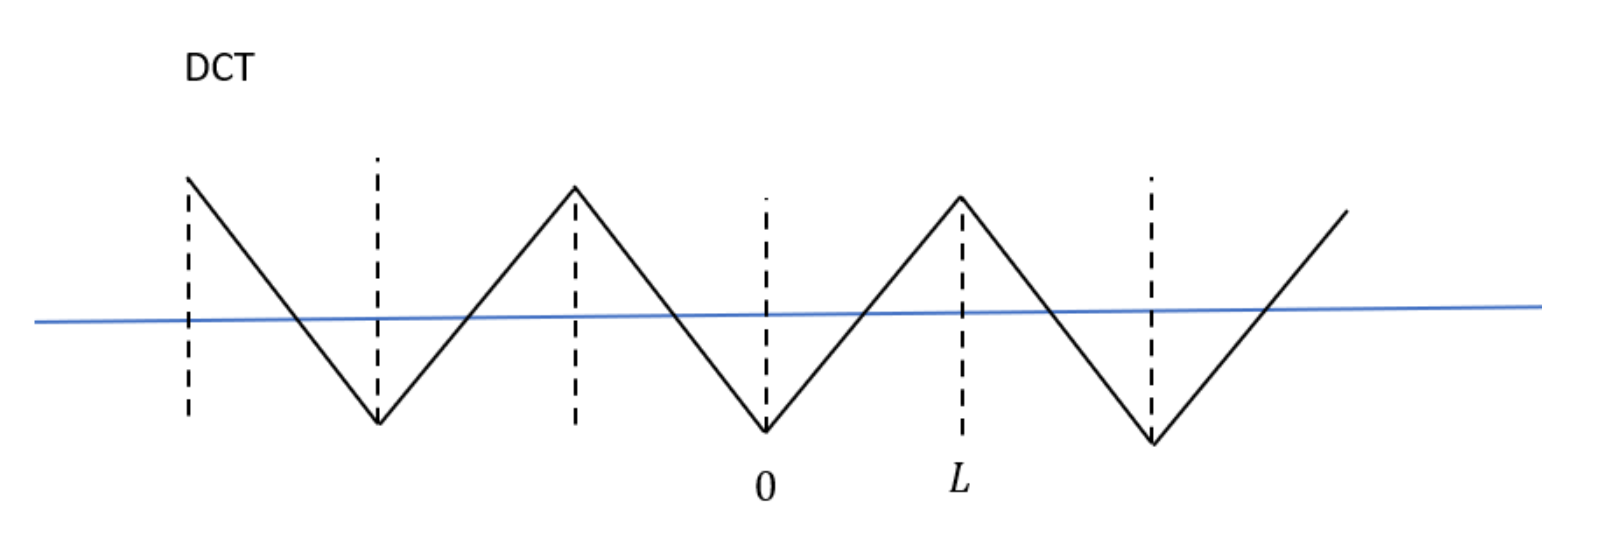

Notice here, a mirror image of the function from 0 to L is added to the left and the right, creating a symmetric function over the interval of 2L.  This pattern is produced since the cosine function itself is a symmetric function.

This periodic function has an obvious advantage over the periodic function produced by the DFT, there are no discontinuites. Because there are no discontinuties it is easier to approximate the function with fewer terms of the Fourier series. This should pay dividends if we use the DCT to compress a data set relative to the DFT. This is one of the main advantages of the DCT.

There are different types of DCTs, determined by how the function or data series is made symmetrical or equivalenty is mirrored into regions beyond the sampling interval.

In the **Type I DCT** the periodic function looks like this:

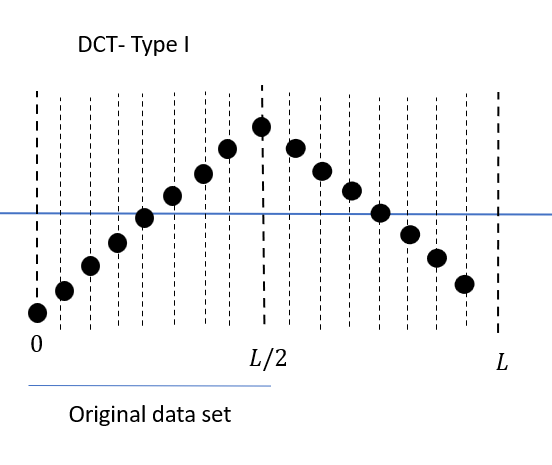

If each data point samples a slice of the function, in Type I the data points lie at the left edge of each slice, $i.e.$, the sampling points lie at $x_n=\frac{nL}{N}$, where $n=0,1,\ldots, N-1$. The symmetry axis of the reflection goes through the end point.

Compare that with **Type II**.

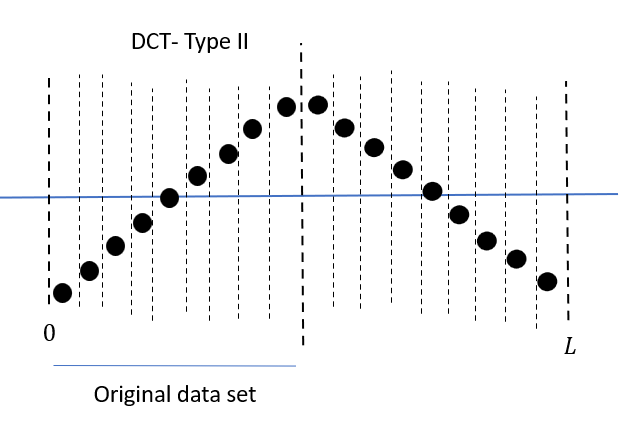

In Type II, the sample points lie in the midpoint of the slice, at $x_n= \frac{nL}{N}+\frac{1}{2}$, and the function is reflected not about an endpoint, but about a point midway between two points. 

The Type-II DCT is the most common DCT type because it is slightly better behaved at the reflection points since the change in the function's derivative is a bit less abrupt than in the Type-I DCT. For this reason we will derive the Type-II DCT, but the derivation of the Type-I DCT is similar (see textbook).

To derive the Type II-DCT of a function or data set over the interval 0 to L, we assume we indeed create a new function or data set by mirroring the samples about the symmetry axis as shown above, i.e. over the interval 2L with 2N sample points

Now we have a symmetric function. But if we redefine this new interval to be $L$ and redefine the number of sampling points to be $N$, this is just a special case of the DFT where $y_{0}=y_{N-1}$, $y_1 = y_{N-2}$, $y_2=y_{N-3}$, or in general $y_n=y_{N-1-n}$. That is, this is the defintion of the mirror symmetry we employ.

Let's start then with the general DFT

$$
c_k = \sum_{n=0}^{N-1}y_n \exp{\left(-i\frac{2\pi kn}{N}\right).}
$$


We can split this into two terms:

$$ 
= \sum_{n=0}^{\frac{1}{2}N-1}y_n \exp{\left(-i\frac{2\pi kn}{N}\right)}+  \sum_{n=\frac{1}{2}N}^{N-1}y_n \exp{\left(-i\frac{2\pi kn}{N}\right)}
$$

We now pull the term $\exp{i\frac{\pi k}{N}}$ out from both terms:

$$
=\exp{i\frac{\pi k}{N}}\left[\sum_{n=0}^{\frac{1}{2}N-1}y_n \exp{\left(-i\frac{2\pi k(n+\frac{1}{2})}{N}\right)}+  \sum_{n=\frac{1}{2}N}^{N-1}y_n \exp{\left(-i\frac{2\pi k(n+\frac{1}{2})}{N}\right)}\right].
$$


We now use the definition of the Type-II DCT,  $y_n=y_{N-1-n}$, in the second term:

$$
=\exp{i\frac{\pi k}{N}}\left[\sum_{n=0}^{\frac{1}{2}N-1}y_n \exp{\left(-i\frac{2\pi k(n+\frac{1}{2})}{N}\right)}+  \sum_{n=\frac{1}{2}N}^{N-1}y_{N-1-n} \exp{\left(i\frac{2\pi k(N-\frac{1}{2}-n)}{N}\right)}\right]
$$

and we make a change of variable,  $N-1-n\rightarrow n$, such that;
$$
=\exp{i\frac{\pi k}{N}}\left[\sum_{n=0}^{\frac{1}{2}N-1}y_n \exp{\left(-i\frac{2\pi k(n+\frac{1}{2})}{N}\right)}+  \sum_{n=0}^{\frac{1}{2}N-1}y_{n} \exp{\left(i\frac{2\pi k(n+\frac{1}{2})}{N}\right)}\right]
$$

which simplifies to:

$$
=2\exp{i\frac{\pi k}{N}}\left[\sum_{n=0}^{\frac{1}{2}N-1}y_n \cos{\left(\frac{2\pi k(n+\frac{1}{2})}{N}\right)}\right]
$$

since $\cos{\theta}=\frac{1}{2}(e^{i\theta}+e^{-i\theta})$.

We define the Fourier coefficients to contain the phase factor out in front. so the coefficients in the DCT are:

$$
\alpha_k=2\sum_{n=0}^{\frac{1}{2}N-1}y_n \cos{\left(\frac{2\pi k(n+\frac{1}{2})}{N}\right)}
$$



The corresponding inverse DCT is:

$$
y_n=\frac{1}{N}\left[\alpha_0+2\sum_{k=0}^{\frac{1}{2}N-1}\alpha_k \cos{\left(\frac{2\pi k(n+\frac{1}{2})}{N}\right)}\right]
$$

Notice that to recover each sample $y_n$ we only need coefficients $\alpha_k$ up to $k=\frac{1}{2}N-1$. Since we also need $\alpha_0$, that means we only need the first $\frac{1}{2}N$ $\alpha_k$'s. But since $N$ here is really twice the number of our original sample size $N$, we can redefine $\frac{1}{2}N\rightarrow N$, and $\alpha_k \rightarrow 2\alpha_k$ so that the DCT and inverse DCT become:



$$
 \boxed{\alpha_k=\sum_{n=0}^{N-1}y_n \cos{\left(\frac{\pi k(n+\frac{1}{2})}{N}\right)}}  \text{DCT}
$$

$$
\boxed{y_n=\frac{1}{N}\left[\alpha_0+2\sum_{k=0}^{N-1}\alpha_k \cos{\left(\frac{\pi k(n+\frac{1}{2})}{N}\right)}\right]} \text{inverse DCT}
$$ 

Where $N$ now is the number of sample points. Note there is no imaginary component in the DCT so if the $y_n$ are real so are the coefficients.

### Practice Exercise: DCT of CO2 data set

Practice coding the DCT. Find the DCT of the MLO CO2 data set, which you can download from Canvas. 
Once you have it working, compare it with the DFT of the same data set, which I include below. 

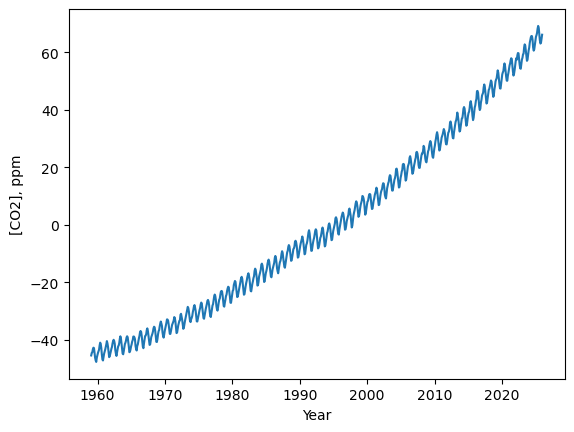

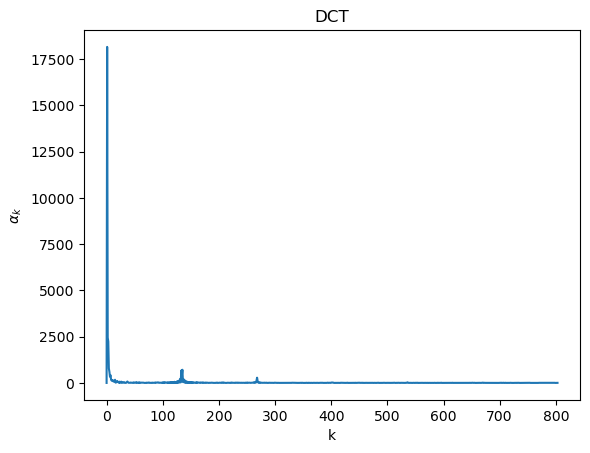

In [24]:
# Calculate DCT for Mauna Loa CO2 data with mean removed

import numpy as np
from cmath import phase
from math import cos, pi
import matplotlib.pyplot as plt


# directory path to data file
path = "G:\\My Drive\\Classes\\Ph322\\Data files\\"
file = "monthly_in_situ_co2_mlo_2026.txt"

# load in the file "monthly_in_situ_co2_mlo.txt"
data = np.loadtxt(path+file)

# col 3 contains date in units of years. Required only for plotting. 
year = data[:,3]

# col 4 contains CO2 in units of ppb
co2 = data[:,4]

# remove the mean
co2 -= np.mean(co2)

#plot CO2 vs year
plt.plot(year, co2, '-')
plt.xlabel("Year")
plt.ylabel("[CO2], ppm")
plt.show()

# calculate the DCT of the CO2 time series
alpha = dct(co2)

# for later use
alphacopy = np.copy(alpha)

# plot the absolute value of the DCT since some coefficients are negative.
plt.plot(abs(alpha), '-')
plt.xlabel("k")
plt.ylabel(r"$\alpha_k$")
plt.title("DCT")
plt.show()



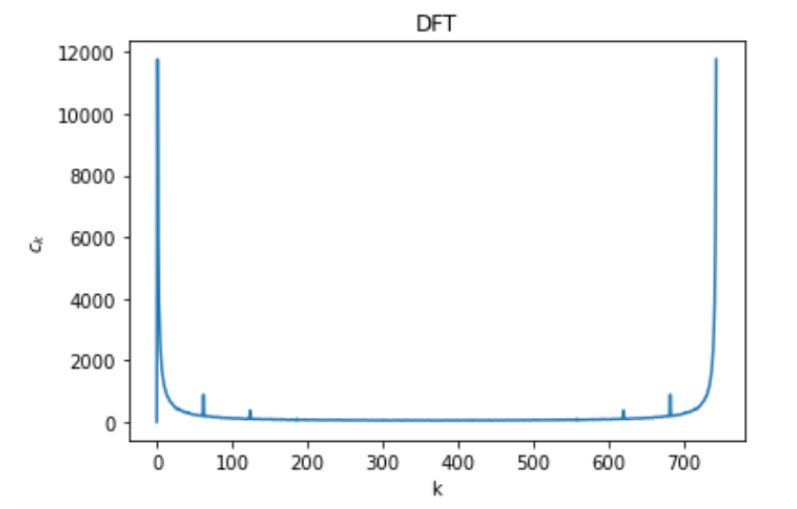

We see some differences between the DFT and the DCT.

For starters, the DCT coefficients aren't repeated in the upper half of the DCT like they are in the DFT. This is because the DCT coefficients don't have complex conjugates because they are real unlike the DFT coefficients.

We again see three peaks in the DCT. The location and the strength of the first peak is about the same in the DCT as it is in the DFT. In the DFT we discovered this first coefficient is for the term that represents the trend of the time series, so this makes sense why it is the same.

Perhaps the biggest difference in the DCT is the strength of the coefficients falls to zero soon after k=1, unlike the strength of the DFT coefficients which decays slowly. You should understand now why this is the case, but we'll get to it shortly. 

Here is a plot that zooms in the y-axis. Compare this plot to the same plot we made for the DFT above.

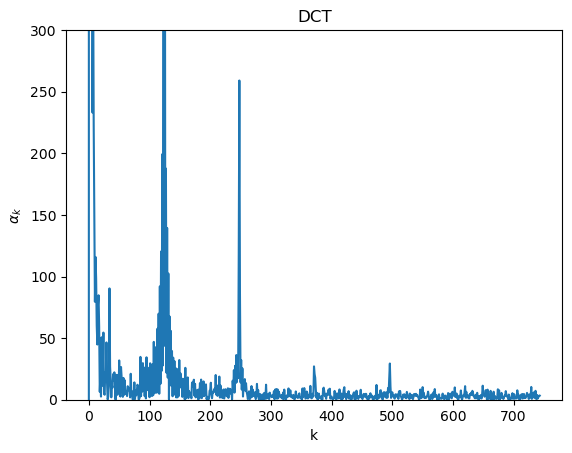

In [29]:
# plot the DCT and zoom in the y-axis about y=0

plt.plot(abs(alpha), '-')
plt.xlabel("k")
plt.ylabel(r"$\alpha_k$")
plt.title("DCT")
plt.ylim(0,300)
plt.show()

Next let's calculate the inverse DCT just to make sure we coded the DCT correctly.

This code performs the inverse DCT on the DCT we just calculated.

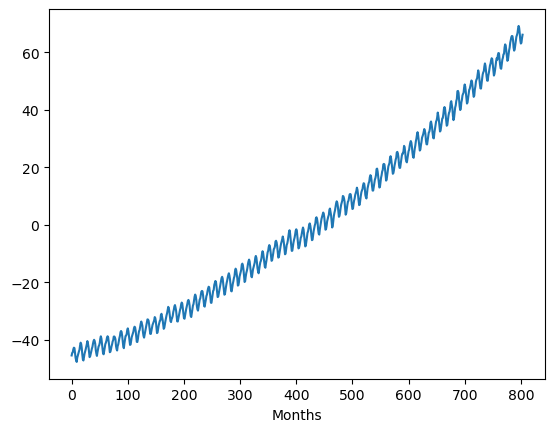

In [61]:
# Calculate the inverse DCT using equation 7.35

import numpy as np
from math import cos,pi
import matplotlib.pyplot as plt


# alpha contains the DCT from above
N = len(alpha)


          
plt.plot(yn)
plt.xlabel("Months")
plt.show()

As expected we recover our data series exactly back.

Next, let's use the inverse DCT to plot the samples outside this sampled range. Remember, to the DCT our data set extends to infinity in both directions. Let's see what it looks like. Before we do, think about what it should look like.

If our original sample interval is 0 to L, we first extend the range to 2L: 

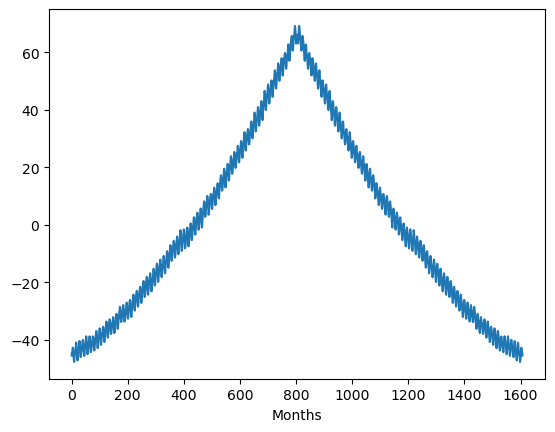

In [62]:
# plot the yn outside the sampled range

# alpha contains the DCT from above
N = len(alpha)

nvalues = np.arange(0,2*N)
yn = np.zeros(len(nvalues),float)

# compute the inverse DCT

# plot the inverse DCT
plt.plot(nvalues,yn)
plt.xlabel("Months")
plt.show()

This is exactly what we expected from the Type-II DCT. We see our sampled data mirrored about a symmetry axis just past our last sample. See how this is different from the DFT?

Let's extend the range to -4L to 4L:

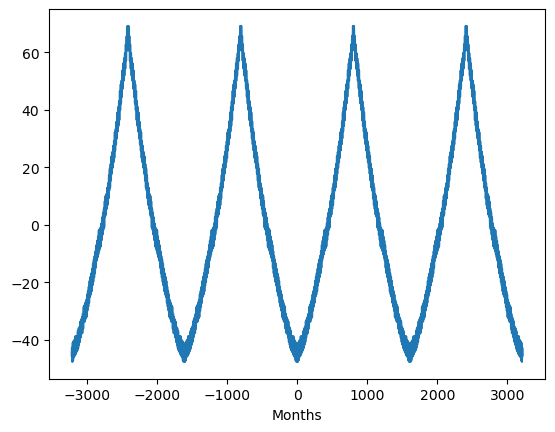

In [63]:
# plot the yn outside the sampled range

# alpha contains the DCT from above
N = len(alpha)

nvalues = np.arange(-4*N,4*N)
yn = np.zeros(len(nvalues),float)

# compute the inverse DCT

# plot the inverse DCT
plt.plot(nvalues,yn)
plt.xlabel("Months")
plt.show()

Again, what we expected. We see our data set mirrored over and over and over.

Remember this is the function the DCT is trying to approximate. Because this function is symmetric with no discontinuities it is much easier to approximate than the DFT.

Let's now run through the same scenario we did for the DFT. 

Assume I want to transmit my CO2 data set to a colleague with limited internet bandwidth. Instead of sending the data set itself, I send the DCT coefficients, hoping that I don't need to send them all in order to make the file smaller.

Remember with the DFT we saw we could only drop 10% of the coefficients without suffering compression artefacts. Is this the same with the DCT? Let's find out.

Let's first drop the lower half of the coefficients, so we cut our file size in half. Can my colleague still recover the data with no significant loss in information and without any compression artefacts?

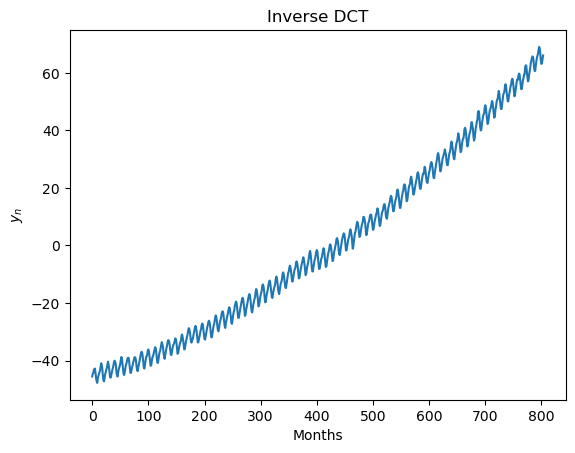

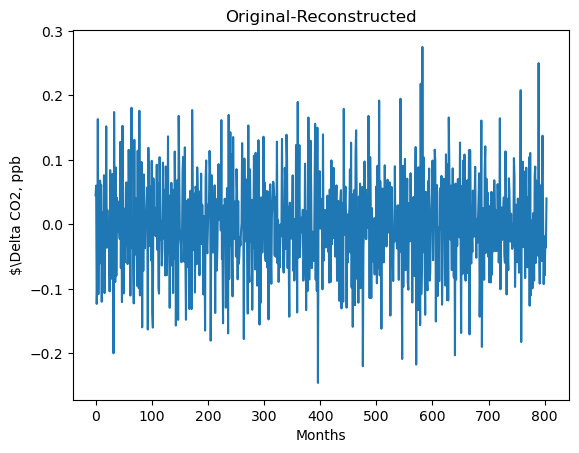

In [25]:
# Remove 50% of the DCT coefficients and reconstruct the data set


          
plt.plot(yn)
plt.xlabel("Months")
plt.ylabel("$y_n$")
plt.title("Inverse DCT")
plt.show()


# calculate the differences between the inverse DCT and original data
residuals = co2-yn

# plot the residuals
plt.plot(residuals)
plt.xlabel("Months")
plt.ylabel("$\Delta CO2, ppb")
plt.title("Original-Reconstructed")
plt.show()

Looks good! The residuals are small and there are no significant artefacts.

Determine for yourself the percentage of coefficients we can drop without introducing artefacts by changing the percentile in the code.

This explains why the DCT is the Fourier transform most often used to compress audio (MP3) and images (JPEG) as well as other digital media.

[Wikipedia page on the Discrete Cosine Transform](https://en.wikipedia.org/wiki/Discrete_cosine_transform)



### Fast Fourier Transform

You may have noticed when running your DFT code, it takes some time for the computer to calculate the DFT. 

This is understandable as the DFT requires a double ```for```-loop over $N$, the number of samples. This is because for each Fourier coefficient we have to loop over $N$ number of samples, and there are $N$ coefficients, or half that if we don't calculate the complex conjugates. So that is $\frac{1}{2}N^2$ calculations.

Since it takes a computer a few minutes to do a billion calculations, if we want to calculate the DFT in a reasonable amount time the largest the sample can be is:

$10^9 = \frac{1}{2}N^2 \rightarrow N\sim 45,000$ data points
 

Considering that might represent only 1 second of an audio file we're compressing, clearly we need a more efficient algorithm.

Enter the **fast Fourier transform (FFT)**.

The FFT uses some mathematical trickery to reduce the number of calculations required to compute the DFT (or DCT). The FFT requires only $N\log_2{N}$ operations. For a data set consisting of $1\times 10^6$ samples, a DFT would require 500 billion calculations, while the FFT requires only about 20 million calculations, a reduction by a factor of 25,000!

**Cooley-Tukey FFT**

We will derive the Cooley-Tukey FFT algorithm (actually originally invented by Gauss - what didn't Gauss do?!) here but there are other FFT algorithms as well. 

This algorithm requires the number of samples to be a power of 2, e.g. $N=2^0,2^1,2^2,\ldots$ (although in practice, there are ways around this requirement, such as adding zeroes to the end of the data set).

We start with the standard DFT:

$$
c_k = \sum_{n=0}^{N-1}y_n \exp{\left(-i\frac{2\pi kn}{N}\right)}
$$

Since we force $N$ to be a power of 2, we can split the summation in two, one for *even* $n$ and one for *odd* $n$.  

We can write the *even* summation terms using a new summation index $r$, where $n=2r$, and $ r=0,1,2,3,\ldots, \frac{1}{2}N-1$:

$$
\text{even terms}_k = E_k= \sum_{r=0}^{\frac{1}{2}N-1}y_{2r} \exp{\left(-i\frac{2\pi k(2r)}{N}\right)} = \sum_{r=0}^{\frac{1}{2}N-1}y_{2r}\exp{\left(-i\frac{2\pi kr}{\frac{1}{2}N}\right)}
$$

We see the even terms have the same form as a DFT, with $\frac{1}{2}N$ samples.

Likewise we can write out the odd terms of the summation using $n=2r+1$, where $ r=0,1,2,3,\ldots, \frac{1}{2}N-1$ again:

$$
\text{odd terms}_k = \sum_{r=0}^{\frac{1}{2}N-1}y_{2r+1} \exp{\left(-i\frac{2\pi k(2r+1)}{N}\right)}
$$

This isn't exactly the DFT since we have the term $(2r+1)$ in the numerator of the exponential argument. So to get it into the DFT form, we first pull out a factor $e^{-i2\pi k/N}$:

$$
 = e^{-i2\pi k/N}\sum_{r=0}^{\frac{1}{2}N-1}y_{2r+1} \exp{\left(-i\frac{2\pi kr}{\frac{1}{2}N}\right)}
$$

Now, the sum is just the DFT of the odd half of the samples. Together we can write the full DFT as:

$$
c_k = \text{even terms}_k+\text{odd terms}_k = E_k + e^{-i2\pi k/N}O_k,
$$

where $E_k$ is the DFT of the even samples and $O_k$ is the DFT of the odd samples.

Notice now the number of calculations required to calculate  $E_k$ is $\frac{1}{2}\left(\frac{1}{2}N\frac{1}{2}N\right) = \frac{1}{8}N^2$, since now the sample size is $\frac{1}{2}N$ (and again assume we don't calculate the complex conjugates). The number of calculations is the same for $O_k$. So the total number of calculations required to compute $c_k$ is $\frac{1}{4}N^2$. 

Since the original DFT required $\frac{1}{2}N^2$ calculations, by splitting the DFT in two pieces like we did here, we cut the number of operations in half. 

And we don't stop there. Since $E_k$ and $O_k$ are DFTs with $N$'s of power of 2, we can divide these into even and odd sums, each now with $\frac{1}{4}N$ samples. 

At this step, $c_k$ is the sum of four DFTs each of size $\frac{1}{4}N$, so the total number of operations is $4\left(\frac{1}{2}\left(\frac{1}{4}N\frac{1}{4}N\right)\right)=\frac{1}{8}N^2$. So we have now reduced the number of steps by a factor of 4. 

The algorithm continues until the number of samples in a single term is just 1. In this case the DFT of a single value is just the value itself, i.e.

$
c_0 = \sum_{n=0}^0 y_ne^0 = y_0
$

If there are $N$ samples, there are $\log_{2}N$ stages where we split each DFT into two new ones. At the $m$th stage there will be $2^m$ sets consisting of $N/2^m$ samples each. 

If we define $E_k^{(m,j)}$ to be the $j$th term at the $m$th stage, where $m=0,1,\ldots, \log_{2}N -1$, and $j=0, 1, \ldots, 2^m -1$, then the decomposition of the DFT looks like this:


$
\begin{array}{cccccccc}
E_k^{(0,0)} &&&&&&& \\
 \downarrow  \searrow &&&&&&& \\
E_k^{(1,0)} & E_k^{(1,1)} &&&&& \\
\downarrow \searrow &  \downarrow  \searrow &&&&&&\\
E_k^{(2,0)} & E_k^{(2,2)} & E_k^{(2,1)}  & E_k^{(2,3)} &&&&\\
\downarrow \searrow & \downarrow \searrow & \downarrow \searrow & \downarrow \searrow &&&&\\
E_k^{(3,0)}&  E_k^{(3,2)} & E_k^{(3,4)} & E_k^{(3,6)}&  E_k^{(3,1)} & E_k^{(3,3)} & E_k^{(3,5)}  & E_k^{(3,7)}\\
\downarrow \searrow & \downarrow \searrow & \downarrow \searrow & \downarrow \searrow & \downarrow \searrow & \downarrow \searrow & \downarrow \searrow & \downarrow \searrow\\
\ldots & \ldots &\ldots &\ldots& \ldots &\ldots &\ldots& \ldots\\
y_0 & y_1 & y_2 &\ldots &\ldots &\ldots &\ldots & y_{N-1}\\
\end{array}
$

where 

$E_k^{(m,j)} = E_k^{(m+1,j)}+e^{-i2\pi 2^m k/N}E_k^{(m+1,j+2^m)}
$

Note the last row consists of just the $N$ samples, which is the coeffcient $c_0$. 

The FFT algorithm proceeds with the bottom step, then using the equation above to calculate the coefficients in the row above until we get back to the top row, at which point we have recoved the $c_k$ coefficients of the DFT. 

At each of the $\log_2N$ stages we calculate $N$ coefficients, so the number of operations is $N\log_2N$. As mentioned above this is far fewer operations than in the regular DFT. 



### Python FFT functions

We will not code the FFT from scratch since the algorithm is rather tricky. The ```numpy.fft``` module provides a number of functions we can use to calculate FFTs. The functions are straightforward to use:

```np.fft.rfft``` - Calculates the FFT for a set of real data, i.e. not complex. For a data set with $N$ samples it will return $\frac{1}{2}N +1$ coefficients, since the rest are just the complex conjugates. Note, your sample size does not need to be a power of 2. The function is smart enough to pad data appropriately. 

```np.fft.irfft```  - Calculates the inverse FFT. Although in general you need to have all coefficients for the inverse transform, irfft will calculate the complex conjugates from just the first half of the coefficients.



Let's use these to calculate the FFT and inverse FFT of the MLO CO2 time series.


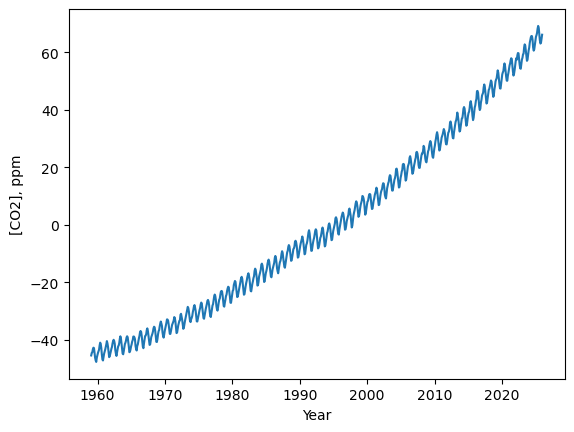

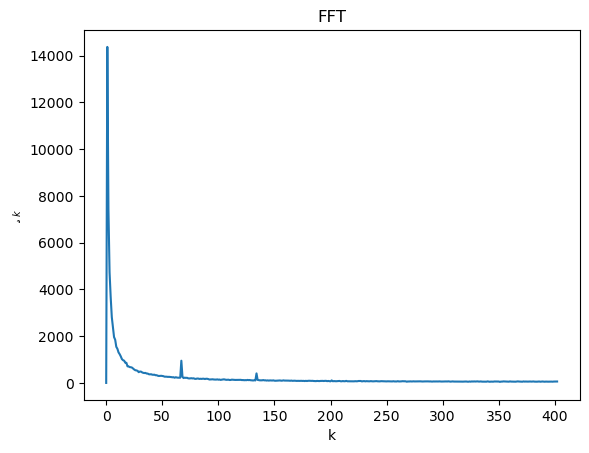

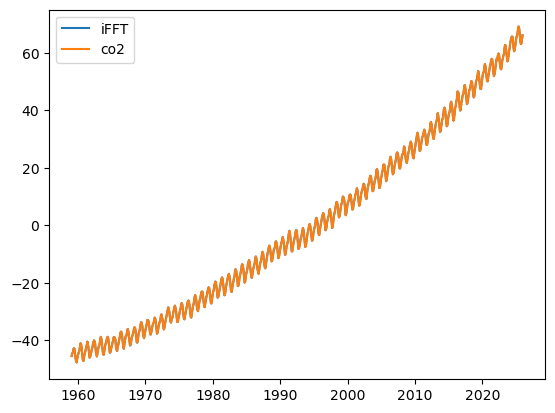

In [65]:
# Calculate the FFT of the MLO time series using the numpy rfft function.



# plot the FFT
plt.plot(abs(c), '-')
plt.xlabel("k")
plt.ylabel(r"$\c_k$")
plt.title("FFT")
plt.show()

# calculate the inverse FFT from coefficients
y = irfft(c)
plt.plot(year, y, label="iFFT")
plt.plot(year, co2, label="co2")
plt.legend()
plt.show()

The calculation of the FFT is almost immediate, and we get back the same coeffcients as with the DFT.

There is also a fast DCT function in the scipy.fftpack module:

```python
scipy.fftpack.dct(x, type=2)
```

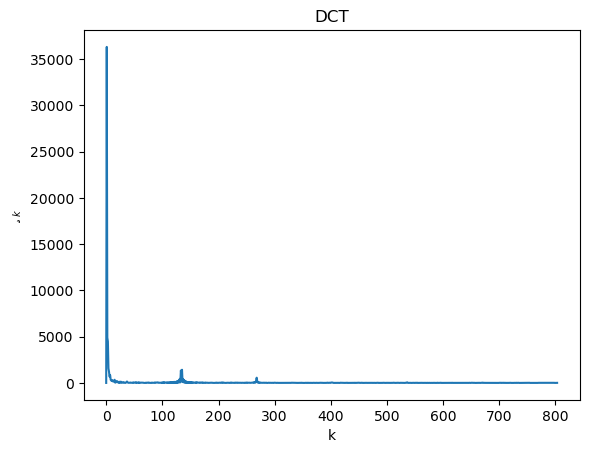

In [66]:


# plot the DCT
plt.plot(abs(c), '-')
plt.xlabel("k")
plt.ylabel(r"$\c_k$")
plt.title("DCT")
plt.show()